In [1]:
%load_ext autoreload
%autoreload 2 
    

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')


from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup



from neurodsp import spectral

from scipy import signal
import scipy

import h5py
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

from neurodsp import filt
from neurodsp.timefrequency import amp_by_time, phase_by_time
from neurodsp.plts import plot_time_series, plot_instantaneous_measure
from neurodsp.plts.time_series import plot_bursts
from neurodsp.burst import detect_bursts_dual_threshold, compute_burst_stats

from scipy.signal import sosfiltfilt, butter

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import statsmodels.api as sm
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor



import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import scipy.stats as stats
import scipy.spatial as sp_spatial

import os



from fooof import FOOOF

from sklearn.linear_model import LinearRegression

sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})


import warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_67350/1527447633.py:58: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


### HELPER FUNCTIONS - to do: move to .py file 

In [3]:
def butter_bandpass(data, fs, filt_freq, order):
    # make sure that the user provides two frequencies for bandpass filter
    try:
        # renormalize frequencies in Hz to fractional scale required by butter
        nyq = 0.5 * fs # nyquist frequency
        f0 = (filt_freq[0]/nyq)
        f1 = (filt_freq[1]/nyq)

        # highpass first
        sos = butter(order, f0, btype = 'high', analog=False, output='sos')
        y = sosfiltfilt(sos, data)

        # then lowpass
        sos = butter(order, f1, btype = 'low', analog=False, output='sos')
        y = sosfiltfilt(sos, y)
        
        return y
    
    except:
        print("filt_freq must have two frequencies for a bandpass filter")

In [4]:
def get_patch_fs_metadata(metadata_file, cell_num):
    
    metafile = pd.read_excel(metadata_file, sheet_name='Sheet1')
    #get index for cell
    cells = metafile['Cell']
    index_cell = cells[cells == "c"+str(cell_num)].index[0]
    
    #get path fs for cell
    
    patch_fs = metafile['Patch Samp. Freq. (Hz)'][index_cell]
    
    return patch_fs
    

In [5]:
def upper(df):
    '''Returns the upper triangle of a correlation matrix.
    You can use scipy.spatial.distance.squareform to recreate matrix from upper triangle.
    Args:
      df: pandas or numpy correlation matrix
    Returns:
      list of values from upper triangle
    '''
    try:
        assert(type(df)==np.ndarray)
    except:
        if type(df)==pd.DataFrame:
            df = df.values
        else:
            raise TypeError('Must be np.ndarray or pd.DataFrame')
    mask = np.triu_indices(df.shape[0], k=1)
    return df[mask]

In [6]:
metadata_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Data Summary.xlsx'
patch_fs_c42 = 50023.8986874656


In [7]:
npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate


npx_channels = 384
npx_patch_channel = 161

data_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/'

out_lfp_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/'

out_npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'

out_patch_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/'

cell_ids = ['c42', 'c42']

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook 

#load_spe1_data(data_path, lfp_fs, npx_fs, patch_fs, cell_ids, npx_channels, npx_patch_channel, out_lfp_path, out_npx_path, out_patch_path)



## Cell 42  (Whole patch, IC)
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 42

#### Step 0: Get loaded data

In [8]:
lfp_c42= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_c42 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'


In [15]:
#get cell number 
cell_num = lfp_c42.split('/')[len(lfp_c42.split('/'))-1].split('_')[0]


#get patch data 
patch_filt_c42 = np.load(patch_c42)
patch_c42_one_ms = float(patch_fs_c42  / 1000)
patch_times_c42 = np.arange(0, np.shape(patch_filt_c42 )[0]) / patch_c42_one_ms # in ms instead of sec

### Compute patch clamp spike features for cell 42

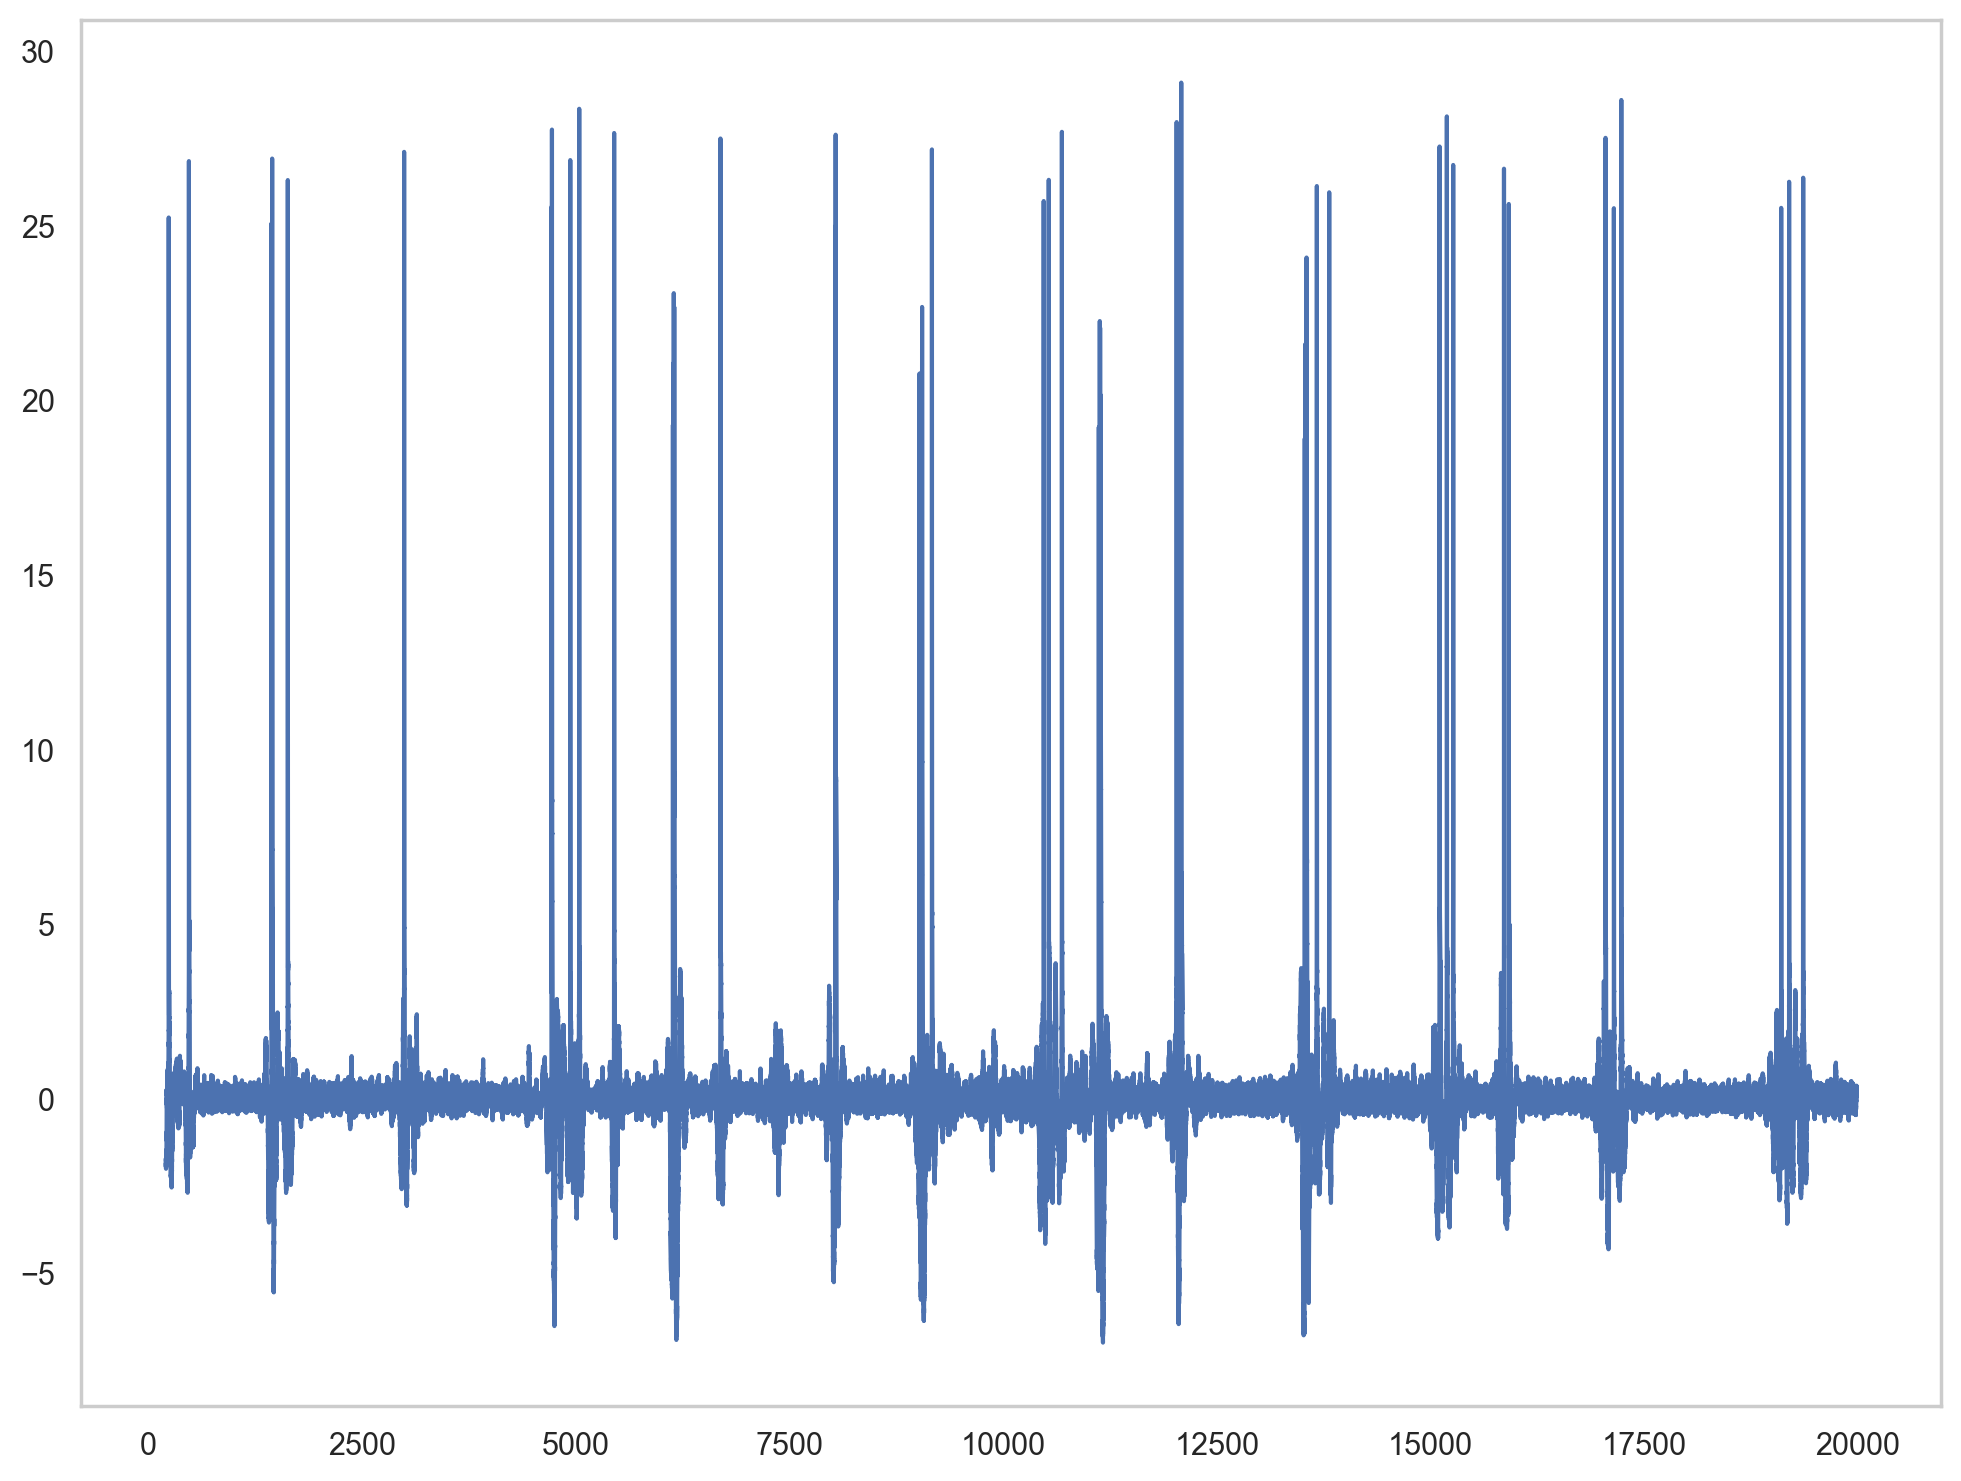

In [16]:
plt.plot(patch_times_c42[10000:1000000], patch_filt_c42[10000:1000000])

In [20]:
def compute_alt_features(stim, fs):
    return stim.mean(), stim.std()

#threshold in mVs
sp = Spike(thresh_amp=10, window_length=(5., 5.), smooth_frac=.01)

"""sp.alt(lfp_filt_c42, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))"""

sp.fit(patch_filt_c42, patch_fs_c42, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/1479 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [21]:
sp.df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,236.247080,0.847685,0.996917
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616297,4.364779,966.737925,0.951638,0.987640
2,1.009075,0.70,1.232428,24.959544,1.20,0.629029,1.388962,1.885119,7.736302,0.981525,0.997816
3,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,0.779627,0.821644,0.999190
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.099952,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1474,-0.909969,1.02,4.727512,11.676022,3.28,0.151212,0.276106,4.721465,0.279866,0.933486,0.996783
1475,-0.909969,1.30,4.727512,11.674754,3.28,0.151188,0.221733,3.783842,1657.967535,0.933486,0.994164
1476,0.095210,1.06,3.676545,11.090664,3.14,-0.015259,0.258909,2.899848,15992.016236,0.072322,0.997072
1477,-0.175349,1.08,4.097930,11.829634,3.78,0.121415,0.237549,4.137374,21926.819556,0.450267,0.997292


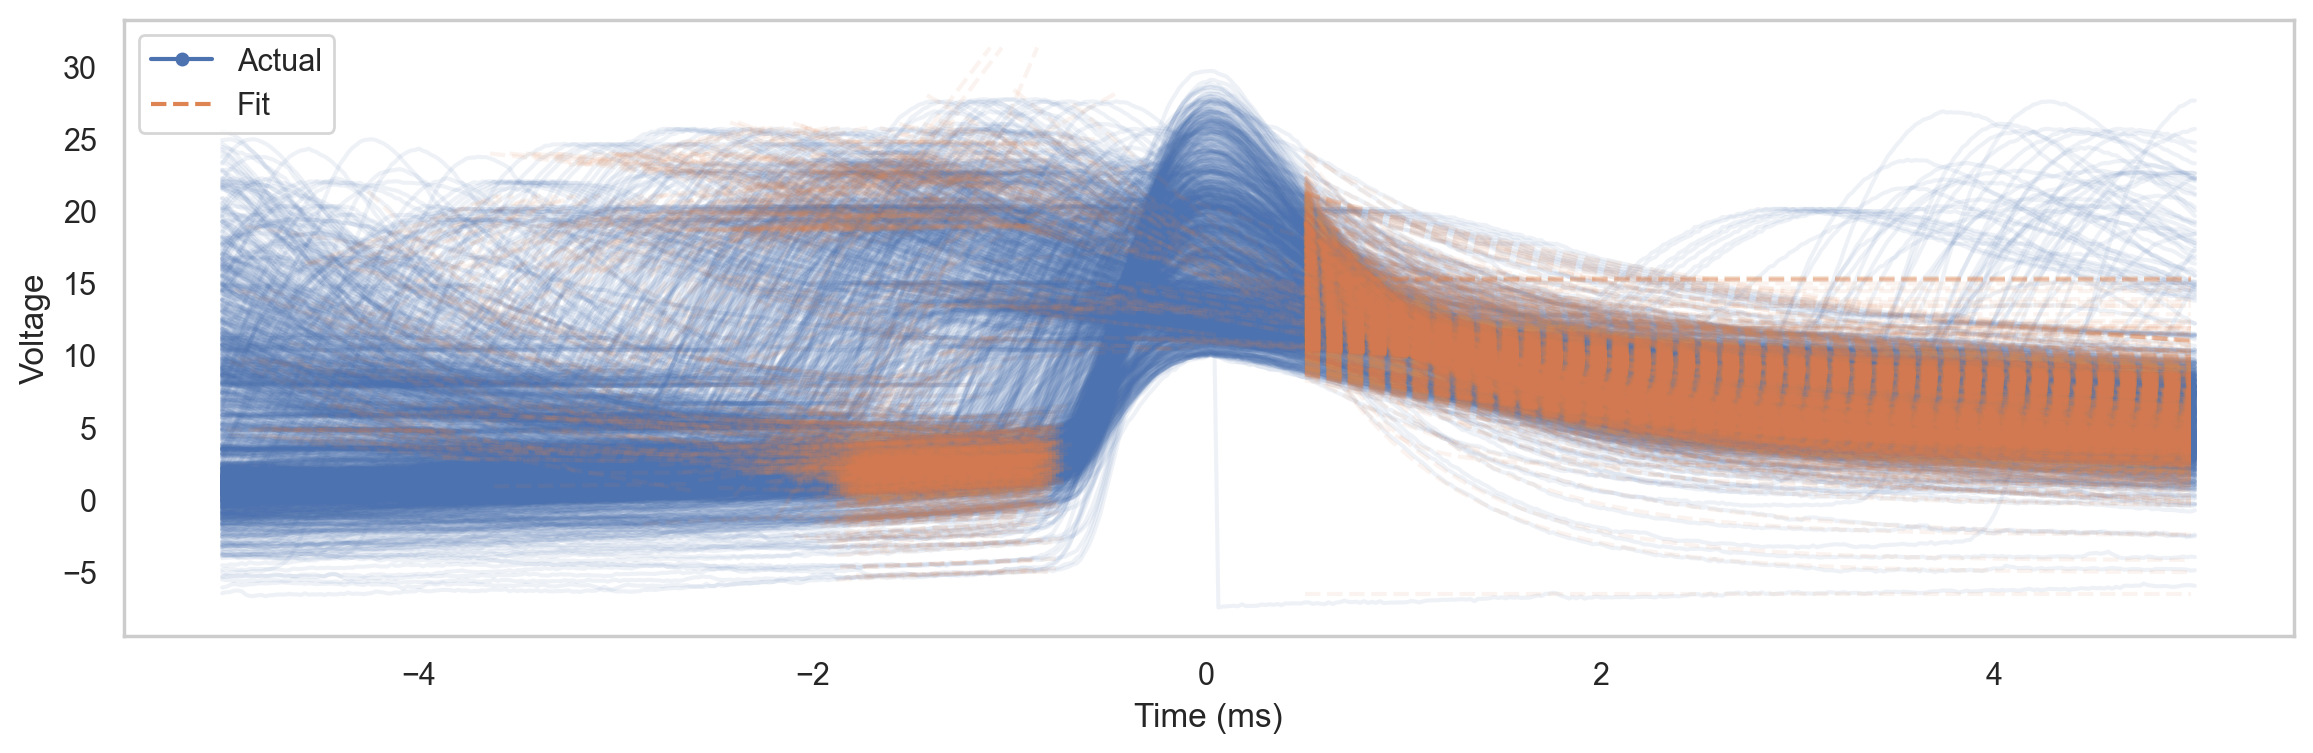

In [22]:
sp.plot()

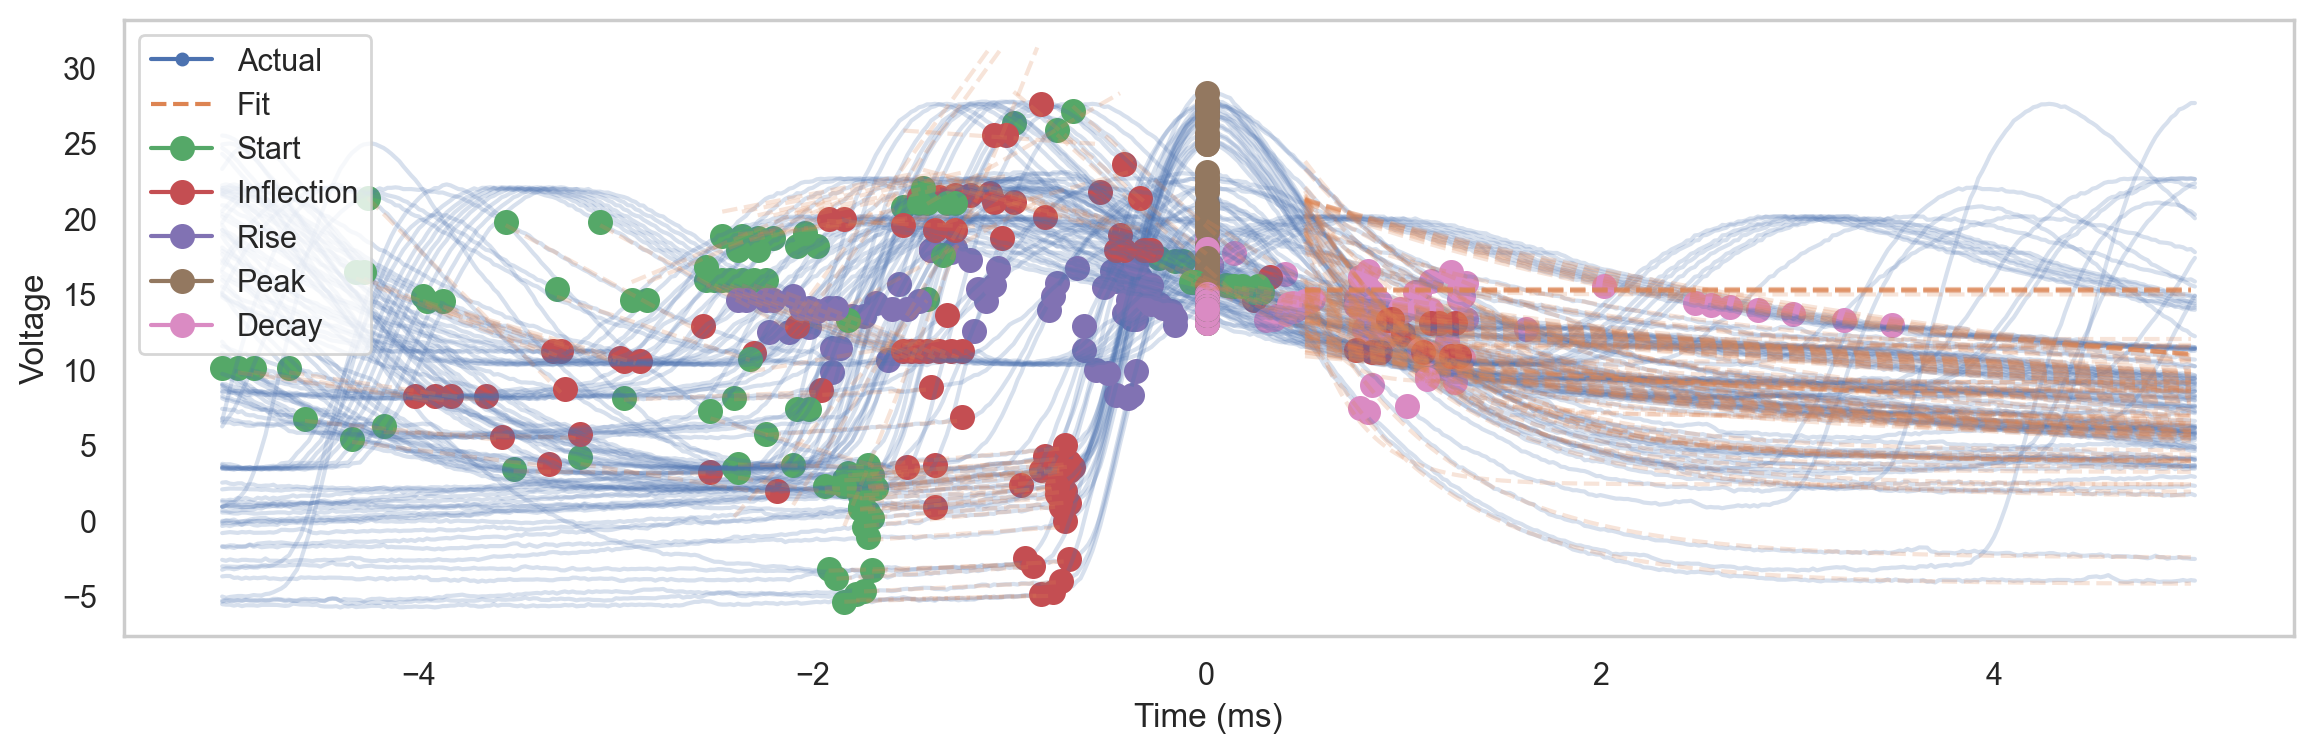

In [23]:
# First 100 fits
sp.plot(inds=np.arange(
    100), mode='full', show_points=True)

#### Plot correlations 

In [51]:
df_features = sp.df_features

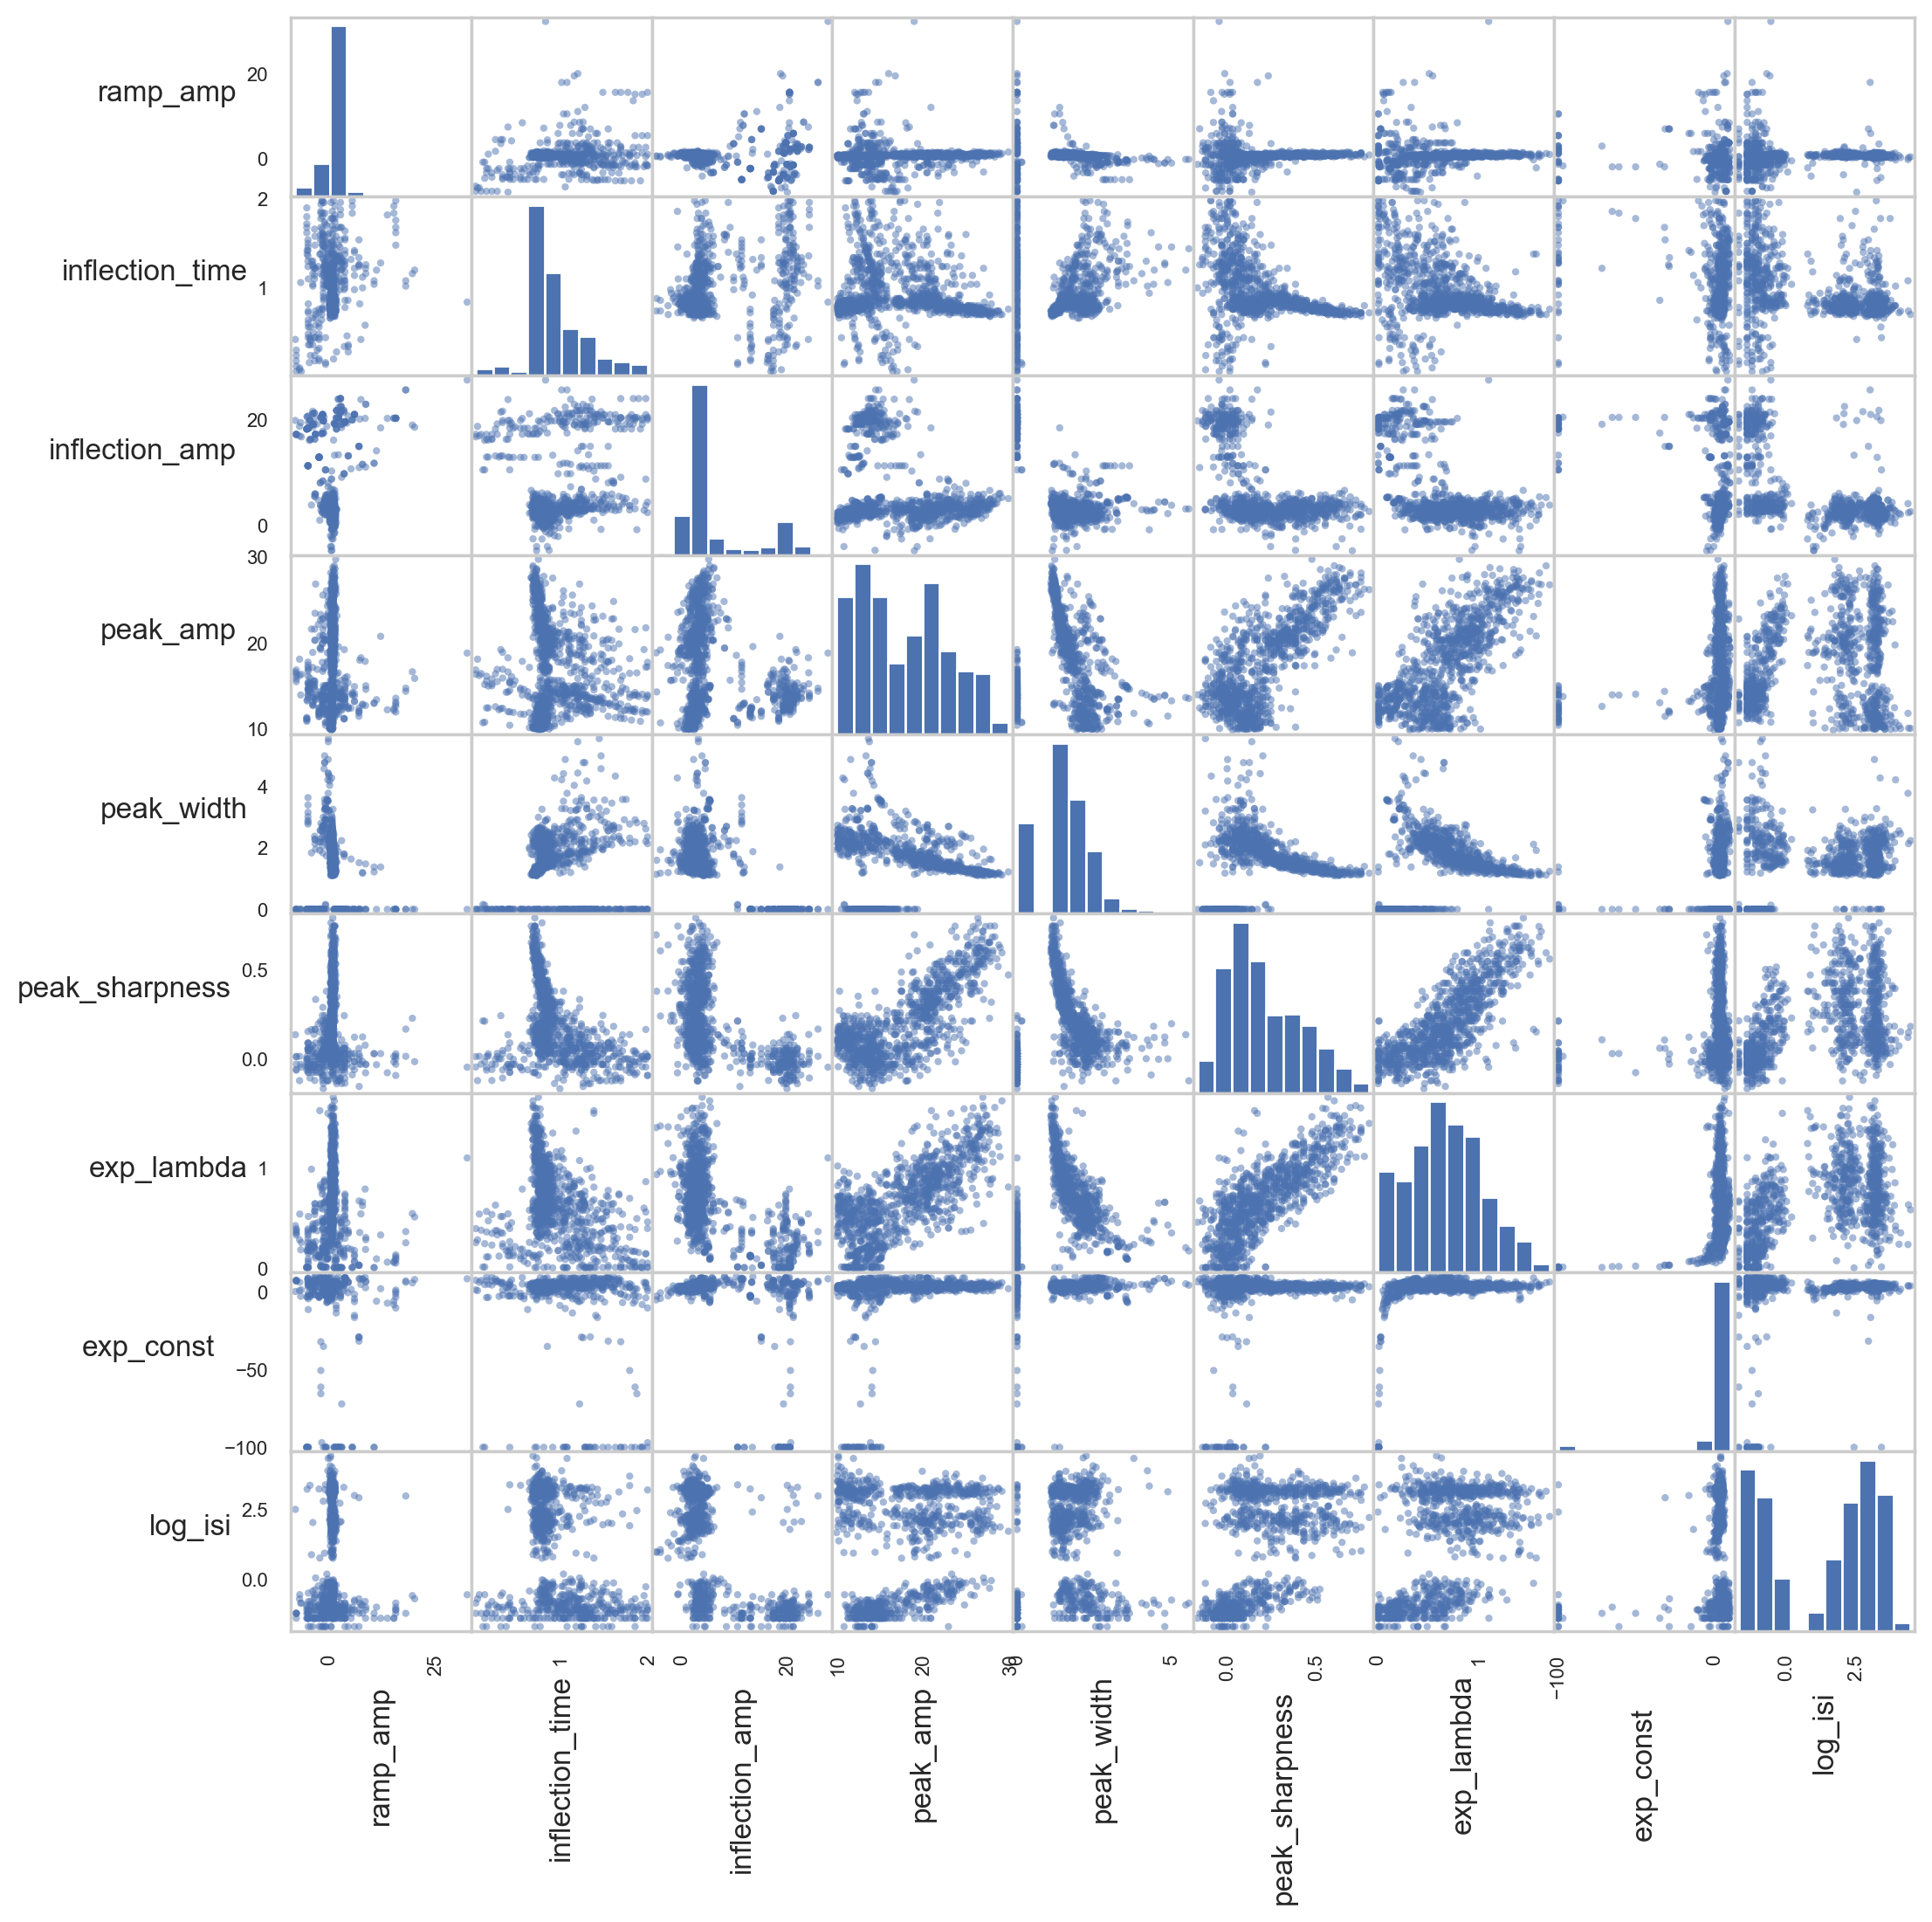

In [52]:
# Ensure inflection times are between 0 and 2 ms
df_features  = df_features .loc[df_features['inflection_time'] > 0.]
df_features = df_features .loc[df_features['inflection_time'] < 2.]
df_features.dropna(inplace=True)
# Remove low r-squares (ramping fits are especially noisy)
df_features = df_features.loc[df_features['r_squared_exp']  >= .5]
df_features = df_features.loc[df_features['r_squared_ramp'] >= .1]
# log10 ISIs
df_features[['isi']] = np.log10(df_features[['isi']])
df_features.rename(columns={'isi':'log_isi'}, inplace=True)
df_features.dropna(subset=['log_isi'], inplace=True)
# drop no-longer-used QC features
df_features = df_features.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_features = df_features.replace([np.inf, -np.inf], np.nan)

axes = pd.plotting.scatter_matrix(df_features, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.show()

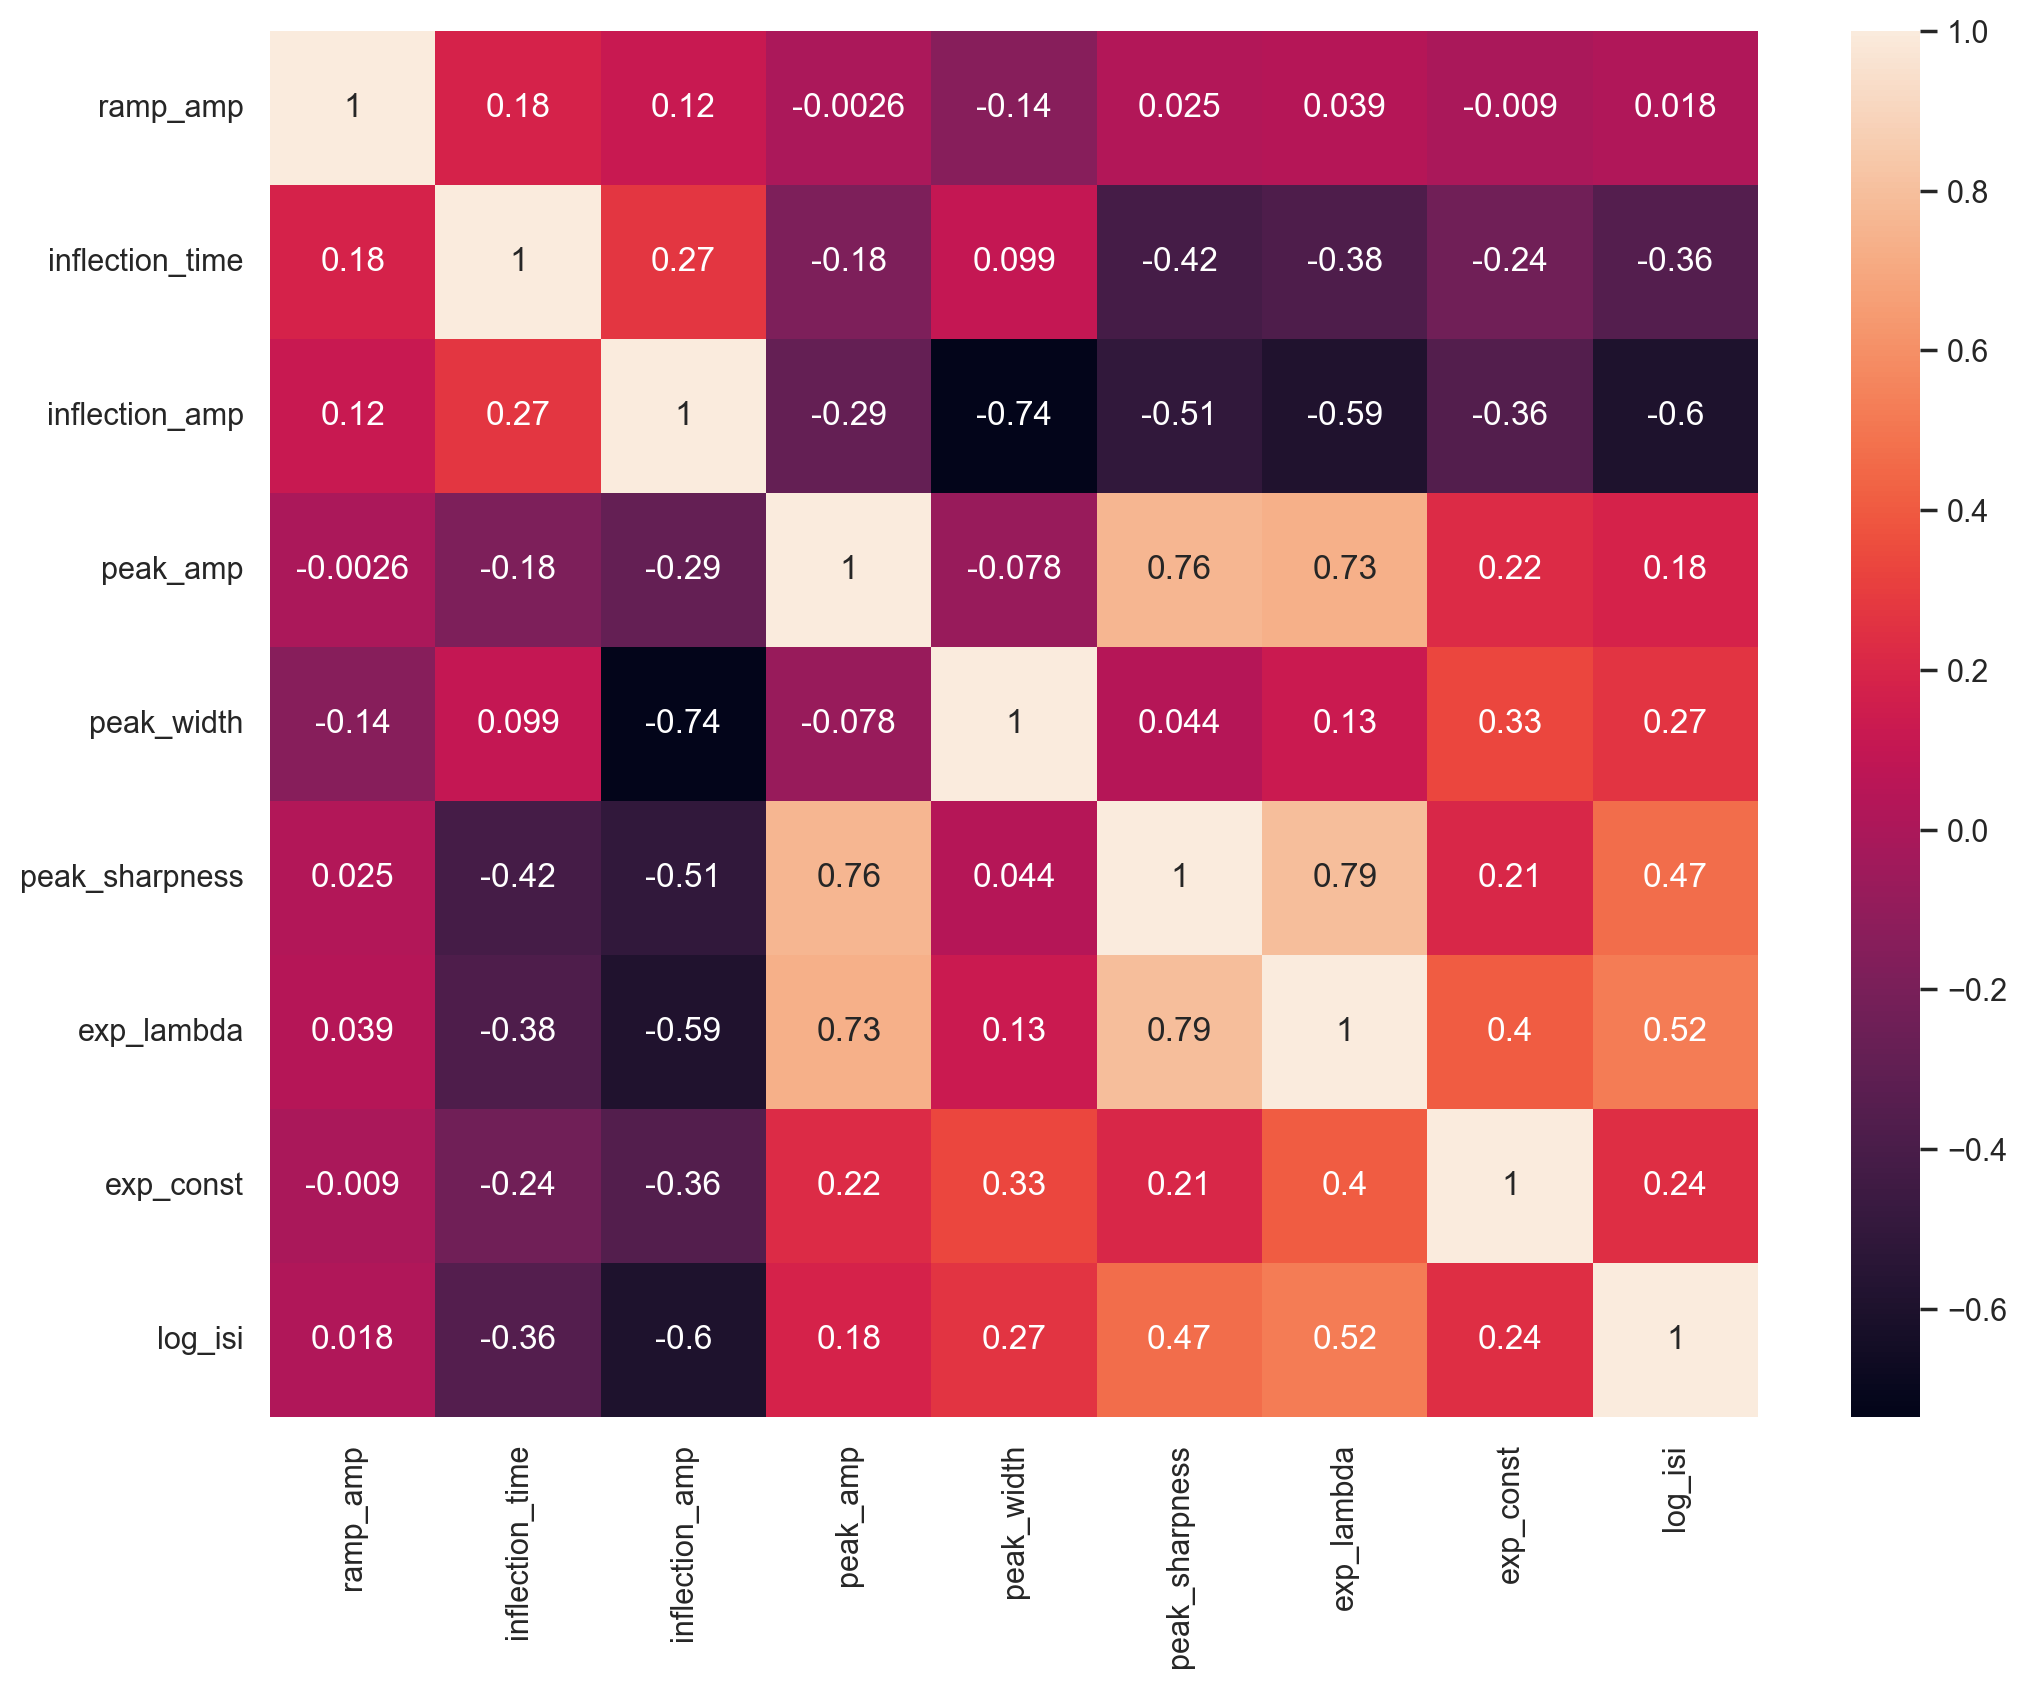

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi
ramp_amp,1.0***,0.18***,0.12***,-0.0,-0.14***,0.03,0.04,-0.01,0.02
inflection_time,0.18***,1.0***,0.27***,-0.18***,0.1**,-0.42***,-0.38***,-0.24***,-0.36***
inflection_amp,0.12***,0.27***,1.0***,-0.29***,-0.74***,-0.51***,-0.59***,-0.36***,-0.6***
peak_amp,-0.0,-0.18***,-0.29***,1.0***,-0.08*,0.76***,0.73***,0.22***,0.18***
peak_width,-0.14***,0.1**,-0.74***,-0.08*,1.0***,0.04,0.13***,0.33***,0.27***
peak_sharpness,0.03,-0.42***,-0.51***,0.76***,0.04,1.0***,0.79***,0.21***,0.47***
exp_lambda,0.04,-0.38***,-0.59***,0.73***,0.13***,0.79***,1.0***,0.4***,0.52***
exp_const,-0.01,-0.24***,-0.36***,0.22***,0.33***,0.21***,0.4***,1.0***,0.24***
log_isi,0.02,-0.36***,-0.6***,0.18***,0.27***,0.47***,0.52***,0.24***,1.0***


In [53]:
#df_features_correlation = df_features.corr()
# Plot the heatmap and annotation on it
sns.heatmap(df_features.corr(), xticklabels=df_features.corr().columns,
            yticklabels=df_features.corr().columns, annot=True)
plt.show()
rho = df_features.corr()
pval = df_features.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

## Linear regression model to predict time of next spike (isi) based on inflection features 

In [54]:
# Selecting relevant features
#X = df_features[['inflection_time', 'inflection_amp', 'ramp_amp']]
X =  df_features.drop(columns=['log_isi'])
y = df_features['log_isi']
# Drop row with NaN value from both X_train and y_train
X_train.dropna( inplace=True)
y_train.dropna(inplace=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
model = LinearRegression()
model.fit(X_train, y_train)

# Model evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)




Mean Squared Error: 1.9922814688982853


In [56]:
#Prediction example
new_data = pd.DataFrame({
    'ramp_amp': [10.961881], 
    'inflection_time': [0.3], 
    'inflection_amp': [18.382591], 
    'peak_amp': [395.954270], 
    'peak_width': [0.62], 
    'peak_sharpness': [79.815607], 
    'exp_lambda': [3.948223], 
    'exp_const': [-7.969183]
})
predicted_isi = model.predict(new_data)
print("Predicted ISI:", predicted_isi)

Predicted ISI: [123.48582639]


### Visualize model

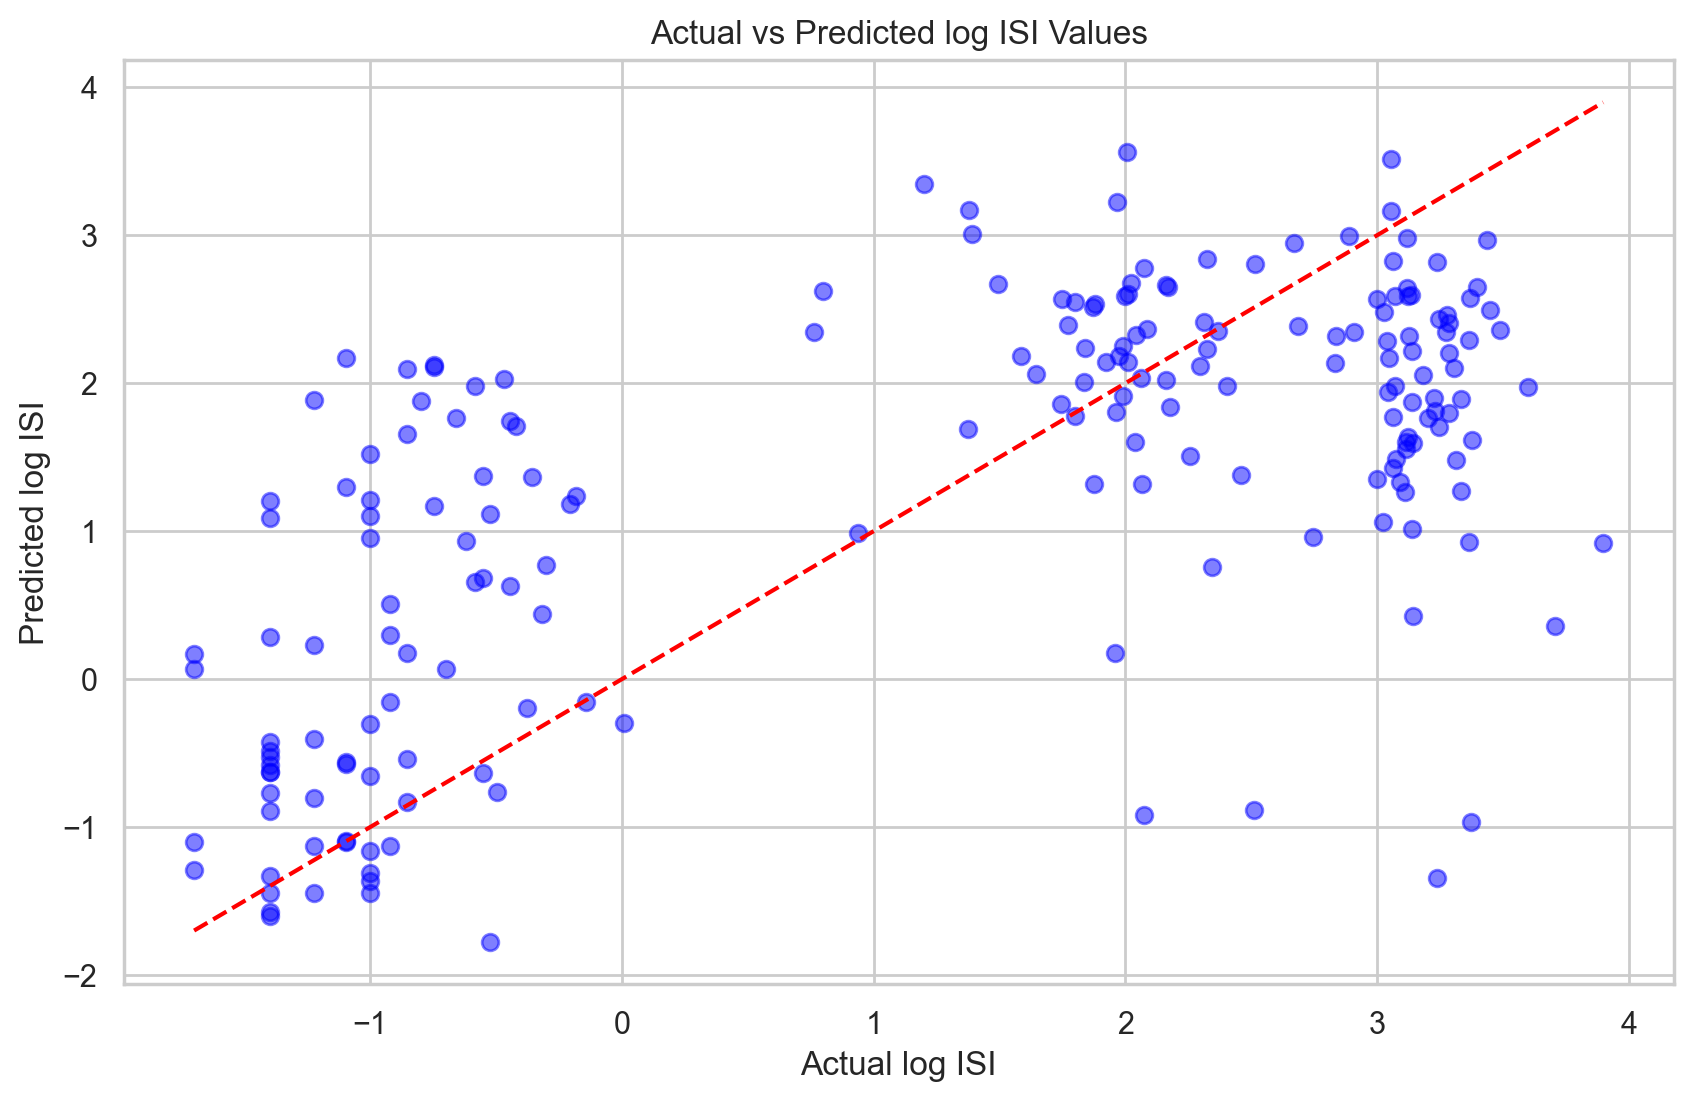

In [57]:
# Plotting actual vs predicted log ISI values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual log ISI')
plt.ylabel('Predicted log ISI')
plt.title('Actual vs Predicted log ISI Values')
plt.grid(True)
plt.show()

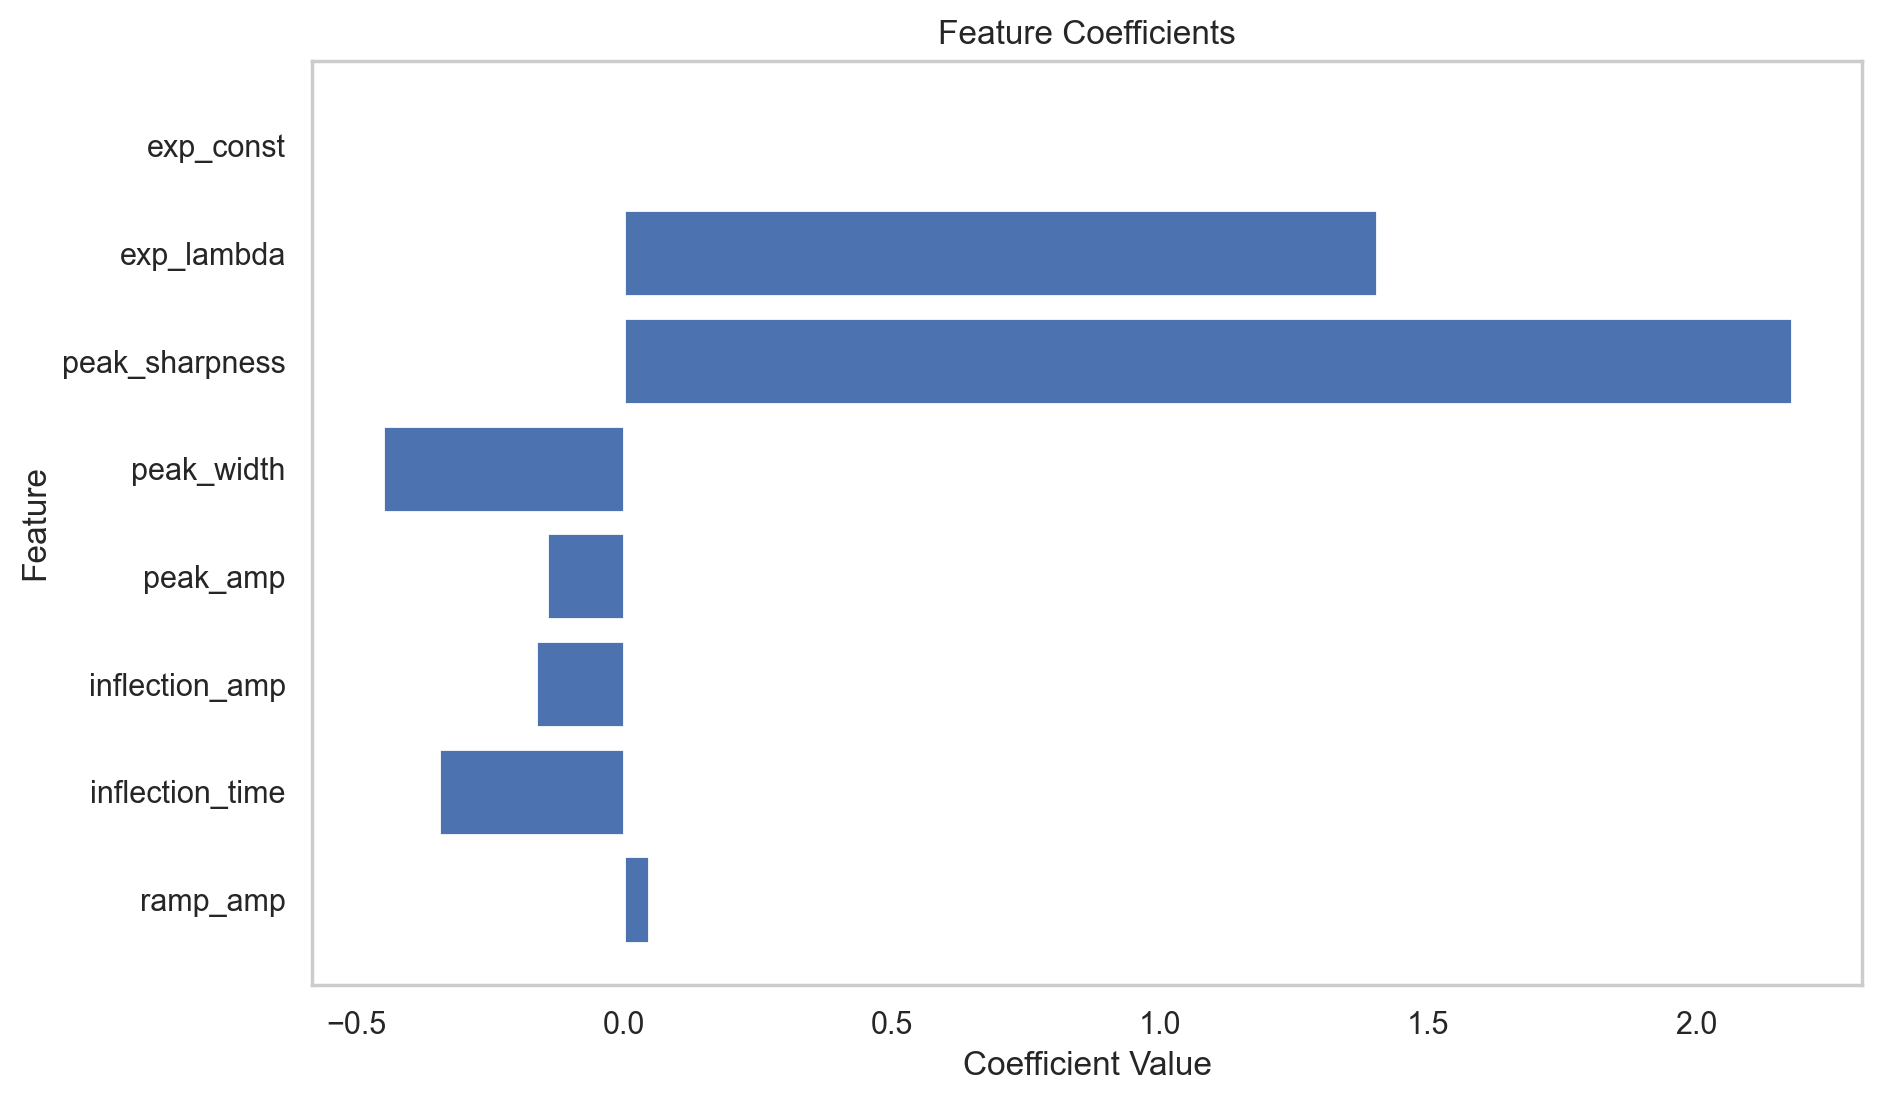

In [58]:
# Extracting feature names and coefficients
feature_names = X.columns
coefficients = model.coef_

# Plotting feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_names, coefficients)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Coefficients')
plt.show()

In [59]:
# Print the coefficients (weights) of the linear regression model
print("Coefficients:", model.coef_)

# Calculate R-squared and adjusted R-squared
r_squared = model.score(X_test, y_test)
adjusted_r_squared = 1 - (1 - r_squared) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print("R-squared:", r_squared)
print("Adjusted R-squared:", adjusted_r_squared)

Coefficients: [ 4.68532943e-02 -3.45653178e-01 -1.64776818e-01 -1.45023952e-01
 -4.50900303e-01  2.17805645e+00  1.40440127e+00  7.87942554e-04]
R-squared: 0.40792536629282306
Adjusted R-squared: 0.3827307010286879


In [60]:
#Get relevant features
# Sort feature names based on absolute coefficient values
feature_coefficients = list(zip(feature_names, coefficients))
sorted_features = sorted(feature_coefficients, key=lambda x: abs(x[1]), reverse=True)

# Selecting top N relevant features
N = 3  # Number of relevant features to select
relevant_features = [feature[0] for feature in sorted_features[:N]]

print("Top", N, "Relevant Features:")
print(relevant_features)

Top 3 Relevant Features:
['peak_sharpness', 'exp_lambda', 'peak_width']


In [61]:
# Selecting relevant features from the DataFrame
X_relevant = df_features[relevant_features]

# Train-test split
X_train_relevant, X_test_relevant, y_train, y_test = train_test_split(X_relevant, y, test_size=0.2, random_state=42)

# Model training
model_relevant = LinearRegression()
model_relevant.fit(X_train_relevant, y_train)

# Model evaluation
y_pred_relevant = model_relevant.predict(X_test_relevant)
mse_relevant = mean_squared_error(y_test, y_pred_relevant)
print("Mean Squared Error (Relevant Features):", mse_relevant)

# Print the coefficients (weights) of the model with relevant features
print("Coefficients (Relevant Features):", model_relevant.coef_)

Mean Squared Error (Relevant Features): 2.479785561064519
Coefficients (Relevant Features): [1.69749715 1.80841045 0.45152714]


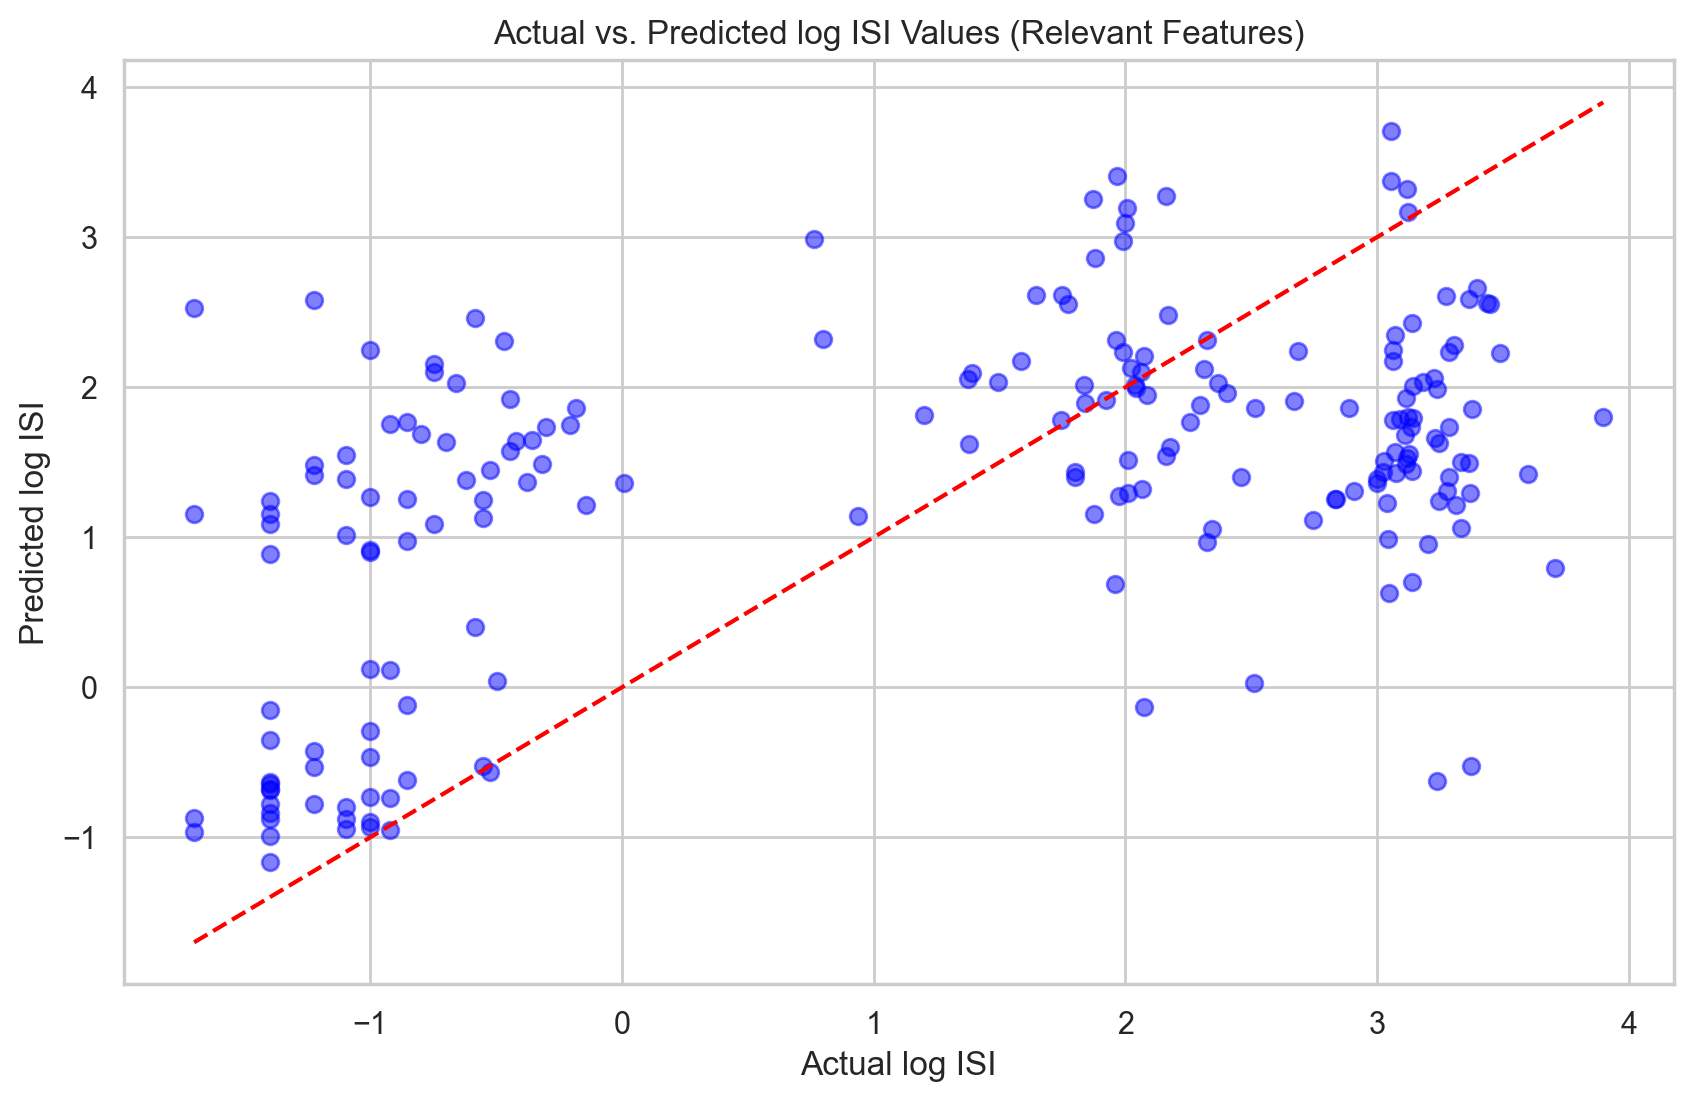

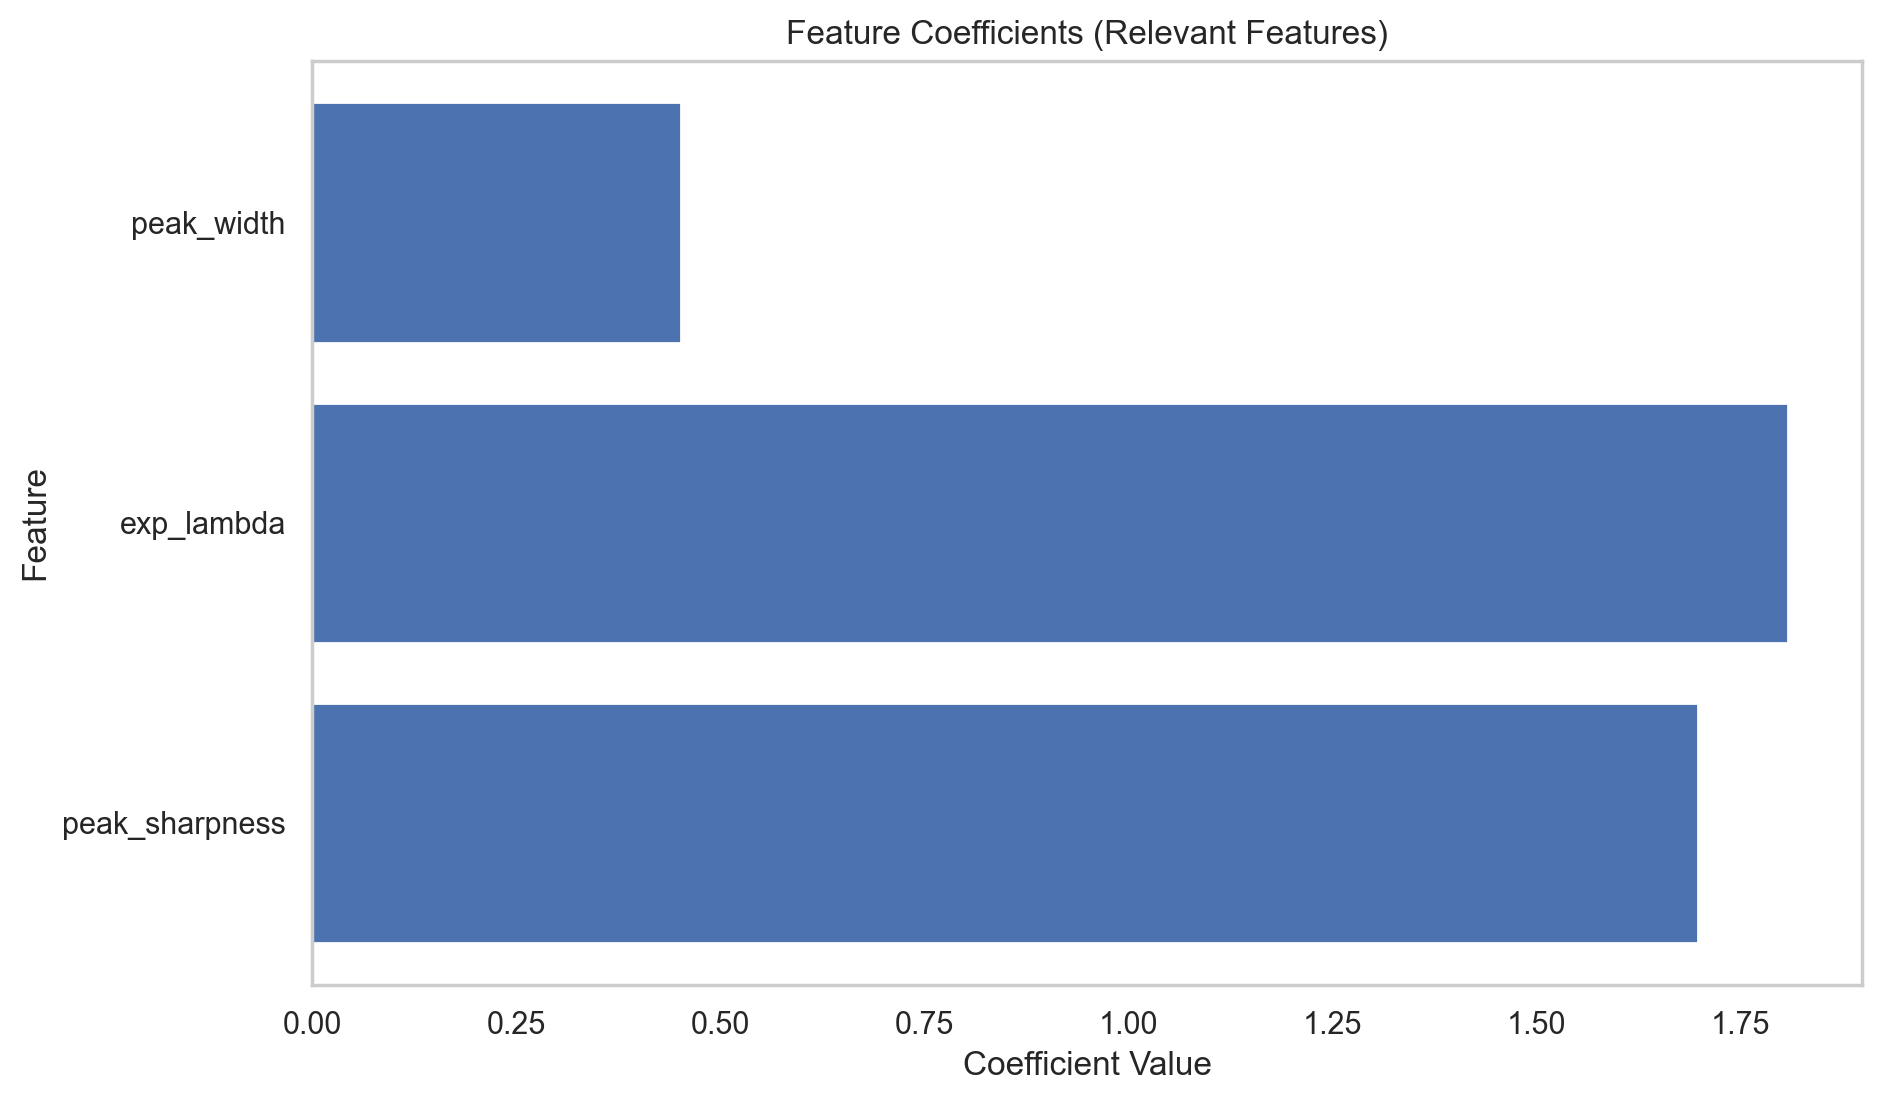

R-squared (Relevant Features): 0.2630468381801828
Adjusted R-squared (Relevant Features): 0.2515916076855742


In [62]:
# Visualize actual vs. predicted log ISI values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_relevant, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual log ISI')
plt.ylabel('Predicted log ISI')
plt.title('Actual vs. Predicted log ISI Values (Relevant Features)')
plt.grid(True)
plt.show()

# Visualize feature importance
importance = model_relevant.coef_
plt.figure(figsize=(10, 6))
plt.barh(relevant_features, importance)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Coefficients (Relevant Features)')
plt.show()

# Calculate R-squared and adjusted R-squared
r_squared_relevant = model_relevant.score(X_test_relevant, y_test)
adjusted_r_squared_relevant = 1 - (1 - r_squared_relevant) * (len(y_test) - 1) / (len(y_test) - X_test_relevant.shape[1] - 1)

print("R-squared (Relevant Features):", r_squared_relevant)
print("Adjusted R-squared (Relevant Features):", adjusted_r_squared_relevant)
